In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score


In [10]:
df=pd.read_csv('Housing.csv')

In [11]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [12]:
df.shape

(545, 13)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [14]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


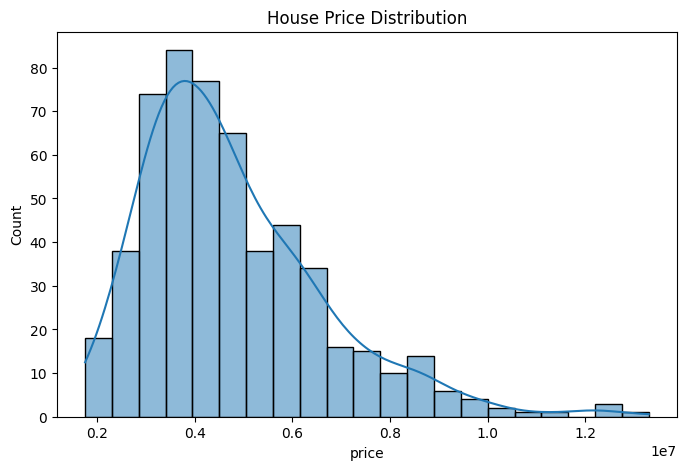

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'],kde=True)
plt.title('House Price Distribution')
plt.show()

In [16]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


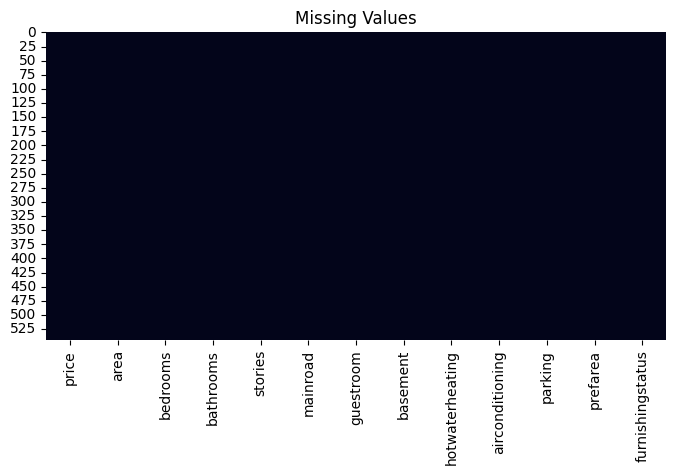

In [17]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(),cbar=False)
plt.title("Missing Values")
plt.show()

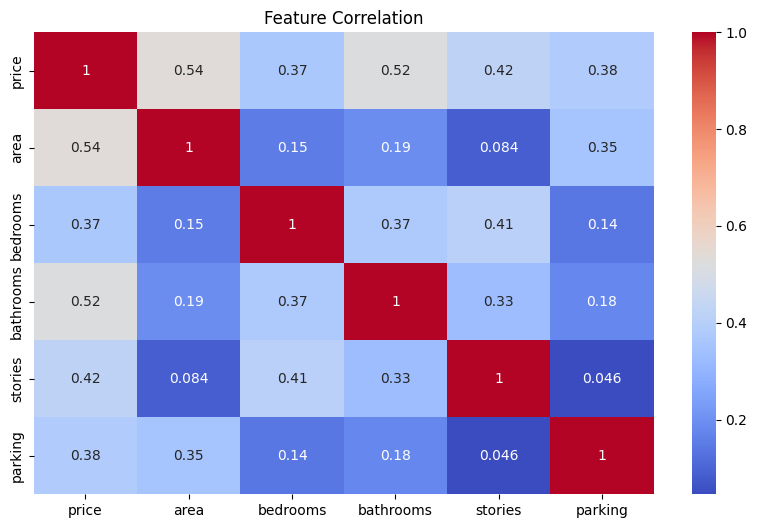

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

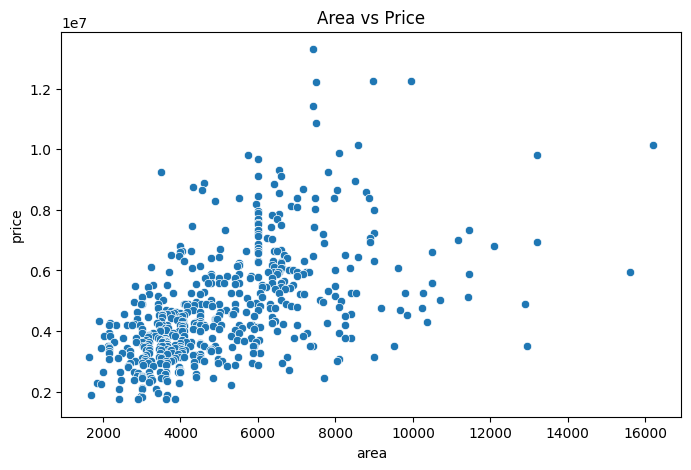

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="area",y="price",data=df)
plt.title("Area vs Price")
plt.show()

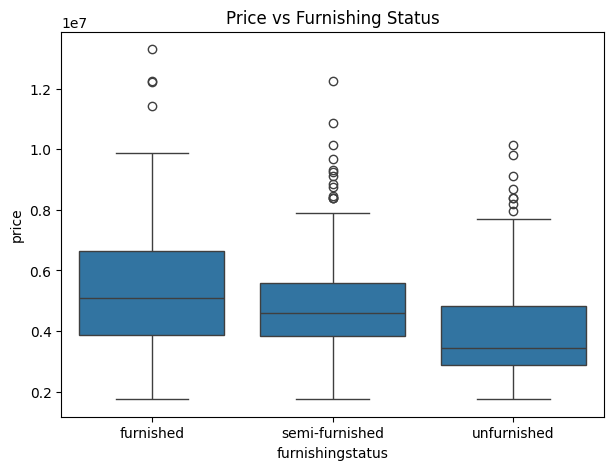

In [20]:
plt.figure(figsize=(7,5))
sns.boxplot(x="furnishingstatus",y="price",data=df)
plt.title("Price vs Furnishing Status")
plt.show()

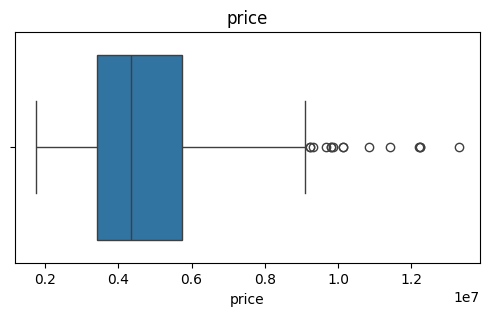

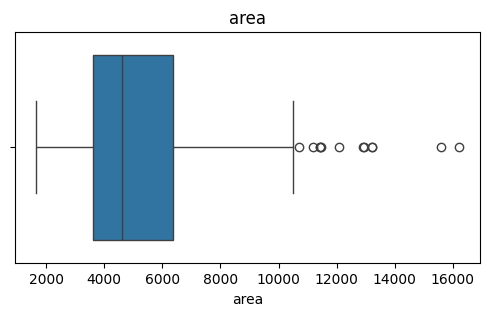

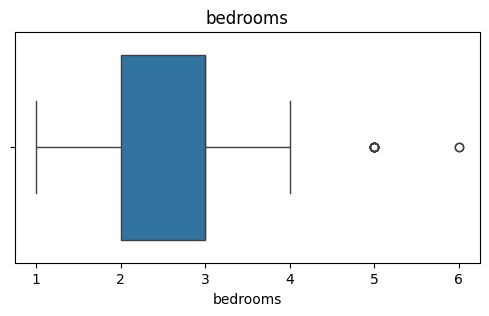

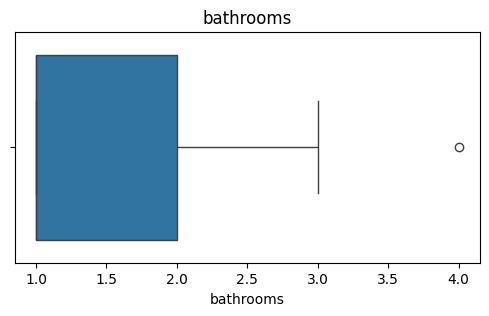

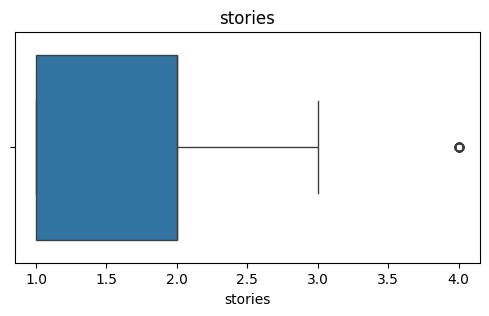

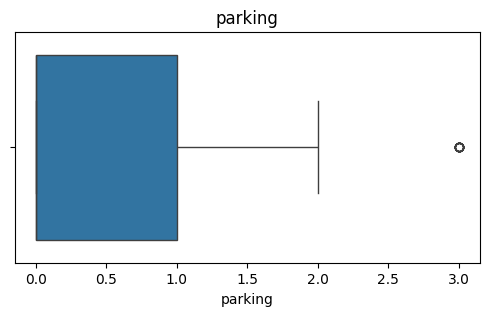

In [21]:
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [22]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df = df[
        (df[col]>=lower) &
        (df[col]<=upper)]

In [23]:
df.shape

(365, 13)

In [24]:
df["price_per_sqft"] = (
    df["price"]/df["area"]
)

In [25]:
df.drop(
    "price_per_sqft",
    axis=1,
    inplace=True
)

In [26]:
df.select_dtypes(
    include="object"
).columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [27]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [28]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
15,9100000,6000,4,1,2,2,True,False,True,False,False,False,True,False
20,8750000,4320,3,1,2,2,True,False,True,True,False,False,True,False
22,8645000,8050,3,1,1,1,True,True,True,False,True,False,False,False
27,8400000,8875,3,1,1,1,True,False,False,False,False,False,True,False
40,7875000,6550,3,1,2,0,True,False,True,False,True,True,False,False


In [29]:
X = df.drop(
    "price",
    axis=1
)

y = df["price"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [32]:
lr=LinearRegression()
lr.fit(X_train_scaled,y_train)
lr_pred=lr.predict(X_test_scaled)

In [33]:
rf=RandomForestRegressor(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)

In [34]:
def evaluate(y_test,pred):

    mse = mean_squared_error(
        y_test,
        pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_test,
        pred
    )

    r2 = r2_score(
        y_test,
        pred
    )


    print("MAE:",mae)
    print("RMSE:",rmse)
    print("R2 Score:",r2)

In [35]:
evaluate(
    y_test,
    lr_pred
)

MAE: 704466.391326915
RMSE: 1036437.728846476
R2 Score: 0.4965319280056799


In [36]:
evaluate(
    y_test,
    rf_pred
)

MAE: 699463.8447488584
RMSE: 1069946.9229612276
R2 Score: 0.46345027732618405


In [37]:
results = pd.DataFrame(
{
"Model":[
"Linear Regression",
"Random Forest"
],

"R2":[
r2_score(y_test,lr_pred),
r2_score(y_test,rf_pred)
],

"MSE":[
mean_squared_error(y_test,lr_pred),
mean_squared_error(y_test,rf_pred)
]

})

results

,Model,R2,MSE
0,Linear Regression,0.496532,1.074203e+12
1,Random Forest,0.463450,1.144786e+12


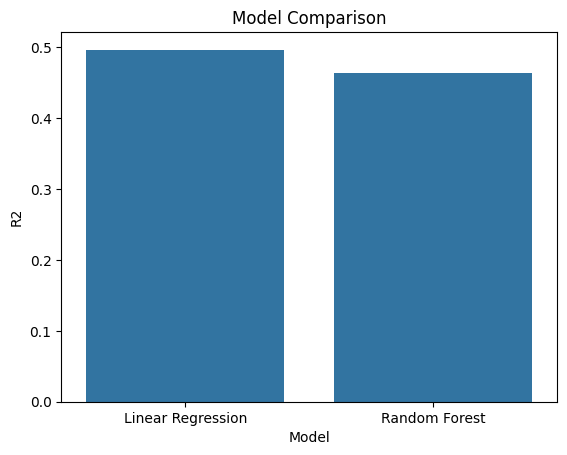

In [38]:
sns.barplot(
    x="Model",
    y="R2",
    data=results
)

plt.title(
"Model Comparison"
)

plt.show()

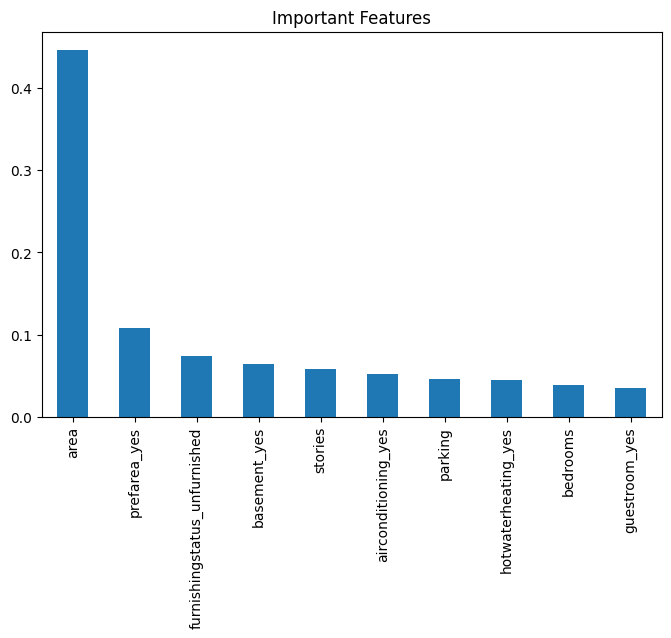

In [39]:
importance = pd.Series(
rf.feature_importances_,
index=X.columns
)

importance.sort_values(
ascending=False
).head(10).plot(
kind="bar",
figsize=(8,5)
)

plt.title(
"Important Features"
)

plt.show()

In [40]:
import pickle


pickle.dump(
    rf,
    open(
    "house_price_model.pkl",
    "wb"
    )
)